In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import norm
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

In [2]:
BINS   = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
LABELS = ["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]

def bucket_mae(df, preds):
    """MAE by moneyness bucket for BS and each model; last row = all options."""
    t = pd.DataFrame({"bucket": pd.cut(df["moneyness (S/K)"], bins=BINS, labels=LABELS),
                      "BS": np.abs(df["price"].values - df["bs_price"].values)})
    for k, p in preds.items():
        t[k] = np.abs(df["price"].values - np.asarray(p))
    out = t.groupby("bucket", observed=True).mean()
    out.insert(0, "n", t.groupby("bucket", observed=True).size())
    out.loc["ALL"] = [len(t)] + list(t.drop(columns="bucket").mean())
    return out.astype({"n": int})

In [5]:
spx = pd.read_csv("data/processed/SPX_cleaned.csv")
spx["date"] = pd.to_datetime(spx["date"])
spx["exdate"] = pd.to_datetime(spx["exdate"])
print(spx.shape)
print(spx["date"].min(), spx["date"].max())

spx.head()

(7688150, 17)
2020-08-31 00:00:00 2025-08-29 00:00:00


,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility,rate,days_to_maturity,T,q
0,108105,2020-08-31,2020-09-18,100.0,3402.5,3408.2,0,611,133485146,3500.31,35.003100,3405.35,0.111899,0.002148,18,0.049315,0.01589
1,108105,2020-08-31,2020-09-18,1000.0,2503.2,2508.0,0,37663,130915017,3500.31,3.500310,2505.60,0.111899,0.002148,18,0.049315,0.01589
2,108105,2020-08-31,2020-09-18,1100.0,2403.4,2407.9,0,96,130915018,3500.31,3.182100,2405.65,0.111899,0.002148,18,0.049315,0.01589
3,108105,2020-08-31,2020-09-18,1200.0,2303.5,2307.9,0,19,129372797,3500.31,2.916925,2305.70,0.111899,0.002148,18,0.049315,0.01589
4,108105,2020-08-31,2020-09-18,1250.0,2253.7,2258.0,0,20,129372798,3500.31,2.800248,2255.85,0.111899,0.002148,18,0.049315,0.01589


## 1. Black-Scholes benchmark (call formula)

The closed-form Black-Scholes price is computed for each option as the benchmark against which the machine learning models will later be compared. Since the analysis is restricted to call options, only the call formula is implemented:

C = S·e^(-qT)·N(d1) − K·e^(-rT)·N(d2)

d1 = [ln(S/K) + (r − q + σ²/2)T] / (σ√T)

d2 = d1 − σ√T

In [6]:
d1 = (
    np.log(spx["close"] / spx["strike_price"])
    + (spx["rate"] - spx["q"] + 0.5 * spx["volatility"] ** 2) * spx["T"]
) / (spx["volatility"] * np.sqrt(spx["T"]))

d2 = d1 - spx["volatility"] * np.sqrt(spx["T"])

In [7]:
spx["bs_price"] = (
    spx["close"] * np.exp(-spx["q"] * spx["T"]) * norm.cdf(d1)
    - spx["strike_price"] * np.exp(-spx["rate"] * spx["T"]) * norm.cdf(d2)
)

spx["bs_price"].describe()

count    7.688150e+06
mean     4.168183e+02
std      6.769914e+02
min      0.000000e+00
25%      3.834214e+01
50%      1.692638e+02
75%      4.849242e+02
max      6.298850e+03
Name: bs_price, dtype: float64

In [8]:
spx["bs_error"] = spx["price"] - spx["bs_price"]

print(spx["bs_error"].describe())

count    7.688150e+06
mean     6.311162e+00
std      4.028861e+01
min     -5.092495e+02
25%     -2.365354e+00
50%      3.056414e+00
75%      1.875544e+01
max      2.442015e+02
Name: bs_error, dtype: float64


Black-Scholes shows a small positive mean error (+6.31 points) on the full SPX dataset, indicating a slight systematic underpricing relative to observed market prices — consistent with the AAPL benchmark (+0.15$) and with a more pronounced volatility skew typically observed on index options. The standard deviation (40.29) is far larger than the mean, confirming that this aggregate figure is not representative on its own; the moneyness-bucket breakdown (see diagnostic below) is needed to interpret it correctly

In [9]:
print(spx.nlargest(5, "bs_error")[["date", "moneyness (S/K)", "T", "volatility", "price", "bs_price", "bs_error"]])
print()
print(spx.nsmallest(5, "bs_error")[["date", "moneyness (S/K)", "T", "volatility", "price", "bs_price", "bs_error"]])

              date  moneyness (S/K)         T  volatility    price  \
6909729 2025-04-08         4.982770  0.871233    0.254580  4228.70   
1581116 2021-11-30         1.026292  0.832877    0.120429   480.10   
6909732 2025-04-08        24.913850  0.871233    0.254580  4996.50   
6909734 2025-04-08        12.456925  0.871233    0.254580  4803.85   
6909833 2025-04-08         4.982770  0.947945    0.254580  4224.35   

            bs_price    bs_error  
6909729  3984.498451  244.201549  
1581116   237.725216  242.374784  
6909732  4754.383026  242.116974  
6909734  4561.911882  241.938118  
6909833  3984.594397  239.755603  

              date  moneyness (S/K)         T  volatility   price    bs_price  \
7189407 2025-05-27         0.887122  0.967123    0.369738  135.65  644.899532   
7189408 2025-05-27         0.883812  0.967123    0.369738  127.80  636.856188   
7189406 2025-05-27         0.890457  0.967123    0.369738  144.00  653.033047   
7189405 2025-05-27         0.893817  0.96712

## 2. Dataset split

In [10]:
spx = spx.sort_values("date").reset_index(drop=True)

train_cutoff = spx["date"].quantile(0.70)
val_cutoff = spx["date"].quantile(0.85)

train = spx[spx["date"] <= train_cutoff]
val = spx[(spx["date"] > train_cutoff) & (spx["date"] <= val_cutoff)]
test = spx[spx["date"] > val_cutoff]

print(f"Train: {len(train)} rows, {train['date'].min()} to {train['date'].max()}")
print(f"Validation: {len(val)} rows, {val['date'].min()} to {val['date'].max()}")
print(f"Test: {len(test)} rows, {test['date'].min()} to {test['date'].max()}")

Train: 5388081 rows, 2020-08-31 00:00:00 to 2024-06-04 00:00:00
Validation: 1149725 rows, 2024-06-05 00:00:00 to 2025-01-24 00:00:00
Test: 1150344 rows, 2025-01-27 00:00:00 to 2025-08-29 00:00:00


In [11]:
feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
target_col = "price"

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print("Feature columns:", feature_cols)
print("Target column:", target_col)

Feature columns: ['moneyness (S/K)', 'T', 'rate', 'q', 'volatility']
Target column: price


In [12]:
for name, d in [("train", train), ("val", val), ("test", test)]:
    assert (d["price"] > 0).all() and (d["strike_price"] > 0).all(), name
print("checks ok")

checks ok


### 1.2 Diagnostic: Black-Scholes error by moneyness bucket

Before introducing any machine learning model, the Black-Scholes benchmark error is broken down by moneyness bucket on the validation set. This step is diagnostic: it checks whether the very low *aggregate* Black-Scholes error (computed above) is genuinely representative, or whether it is an artifact of the dataset composition (e.g. a large share of deep in-the-money contracts, for which price is close to intrinsic value and therefore near-trivial to predict).

#### 1.2.1 Black-Scholes error on validation set

In [13]:
# Black-Scholes error on the validation set (benchmark for the exploratory phase)
bs_mae_val = np.abs(val["price"] - val["bs_price"]).mean()
bs_rmse_val = np.sqrt(((val["price"] - val["bs_price"]) ** 2).mean())

print(f"Black-Scholes — SPX validation set ({len(val):,} options)")
print(f"MAE:  {bs_mae_val:.4f}")
print(f"RMSE: {bs_rmse_val:.4f}")

Black-Scholes — SPX validation set (1,149,725 options)
MAE:  18.9511
RMSE: 29.1601


In [14]:
# Black-Scholes error by moneyness bucket — validation set
val_bs_check = val.copy()
val_bs_check["bs_error_abs"] = np.abs(val_bs_check["price"] - val_bs_check["bs_price"])
val_bs_check["moneyness_bucket"] = pd.cut(
    val_bs_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

val_bs_check.groupby("moneyness_bucket", observed=True).agg(
    n_options=("bs_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    median_price=("price", "median"),
)

,n_options,bs_mae,median_price
moneyness_bucket,,,
Deep OTM,21332,2.604380,0.475
OTM,157667,13.499352,5.400
ATM,529060,20.036567,124.475
ITM,272607,24.450231,600.450
Deep ITM,143006,15.347653,1447.500
Very Deep ITM,17812,5.612540,3588.200
Extreme ITM,8241,5.339505,5110.450


#### 1.2.2 Black-Scholes error on test set

In [15]:
# Black-Scholes aggregate error on the test set
bs_mae_test = np.abs(test["price"] - test["bs_price"]).mean()
bs_rmse_test = np.sqrt(((test["price"] - test["bs_price"]) ** 2).mean())

print(f"Black-Scholes — SPX test set ({len(test):,} options)")
print(f"MAE:  {bs_mae_test:.4f}")
print(f"RMSE: {bs_rmse_test:.4f}")

Black-Scholes — SPX test set (1,150,344 options)
MAE:  42.8818
RMSE: 78.3668


In [16]:
# Black-Scholes error by moneyness bucket — test set
test_check = test.copy()
test_check["bs_error_abs"] = np.abs(test_check["price"] - test_check["bs_price"])
test_check["moneyness_bucket"] = pd.cut(
    test_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

bs_bucket_test = test_check.groupby("moneyness_bucket", observed=True).agg(
    n_options=("bs_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    median_price=("price", "median"),
)
bs_bucket_test["bs_mae_over_price"] = bs_bucket_test["bs_mae"] / bs_bucket_test["median_price"]
bs_bucket_test

,n_options,bs_mae,median_price,bs_mae_over_price
moneyness_bucket,,,,
Deep OTM,30051,38.566734,0.425,90.745257
OTM,227962,55.431786,7.250,7.645764
ATM,490931,46.326869,140.900,0.328793
ITM,251452,41.956471,642.050,0.065348
Deep ITM,123621,17.308708,1518.200,0.011401
Very Deep ITM,17799,3.916416,3793.350,0.001032
Extreme ITM,8528,3.603825,5294.725,0.000681


In [17]:
chk = test.copy()
chk["bs_err"] = chk["price"] - chk["bs_price"]          # negative = BS above market
chk["bs_err_abs"] = chk["bs_err"].abs()
chk["month"] = chk["date"].dt.to_period("M")
otm = chk[chk["moneyness (S/K)"] < 0.95]

print(otm.groupby("month").agg(
    n=("bs_err_abs", "size"),
    bs_mae=("bs_err_abs", "mean"),
    bs_mean_err=("bs_err", "mean"),
    hist_vol=("volatility", "mean"),
).round(3))

             n   bs_mae  bs_mean_err  hist_vol
month                                         
2025-01   6129   14.958      -14.910     0.144
2025-02  23866   11.299      -10.666     0.138
2025-03  58389   10.181       -9.360     0.161
2025-04  75071   76.400      -73.789     0.316
2025-05  32989  167.200     -167.200     0.365
2025-06  20059   52.975      -52.436     0.201
2025-07  19403   12.257        9.786     0.108
2025-08  22107   13.024       13.022     0.095


## 3. XGBoost
A gradient-boosted tree model (XGBoost) is trained on the chronological training set, using the validation set for early stopping to prevent overfitting. Default/simple hyperparameters are used for this initial baseline; tuning is deferred to a later iteration.

### 3.1.1 XGBoost - baseline model v1 - old

This first model (baseline) uses the same five inputs as the Black-Scholes benchmark, with the raw option price as target.

In [26]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Best iteration: {model.best_iteration}")
print(f"Best validation RMSE: {model.best_score:.4f}")

Best iteration: 16
Best validation RMSE: 206.6847


In [27]:
val_pred = model.predict(X_val)

val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_mae = mean_absolute_error(y_val, val_pred)
val_r2 = r2_score(y_val, val_pred)

print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation R²: {val_r2:.4f}")

Validation RMSE: 206.6847
Validation MAE: 103.0741
Validation R²: 0.9288


In [28]:
# Baseline XGBoost vs Black-Scholes — error by moneyness bucket (validation set)
val_check_baseline = val.copy()
val_check_baseline["xgb_baseline_pred"] = val_pred
val_check_baseline["xgb_baseline_error_abs"] = (val_check_baseline["price"] - val_check_baseline["xgb_baseline_pred"]).abs()
val_check_baseline["bs_error_abs"] = (val_check_baseline["price"] - val_check_baseline["bs_price"]).abs()

val_check_baseline["moneyness_bucket"] = pd.cut(
    val_check_baseline["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["deep OTM", "OTM", "ATM", "ITM", "deep ITM", "very deep ITM", "extreme ITM"]
)

val_check_baseline.groupby("moneyness_bucket")[["bs_error_abs", "xgb_baseline_error_abs"]].agg(["mean", "count"])

bs_error_abs         xgb_baseline_error_abs        
                         mean   count                   mean   count
moneyness_bucket                                                    
deep OTM             2.604380   21332               3.250542   21332
OTM                 13.499352  157667               7.722491  157667
ATM                 20.036567  529060              28.267466  529060
ITM                 24.450231  272607             125.309977  272607
deep ITM            15.347653  143006             325.457674  143006
very deep ITM        5.612540   17812             704.557545   17812
extreme ITM          5.339505    8241            1093.608979    8241

### 3.1.2 Experiment (v1b): S/K + K + target C

In [29]:
feature_cols_v1b = ["moneyness (S/K)", "strike_price", "T", "rate", "q", "volatility"]
X_train_v1b, X_val_v1b = train[feature_cols_v1b], val[feature_cols_v1b]

model_v1b = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50,
                             eval_metric="rmse", random_state=42)
model_v1b.fit(X_train_v1b, train["price"].values,
              eval_set=[(X_val_v1b, val["price"].values)], verbose=False)

val_pred_v1b = model_v1b.predict(X_val_v1b)
print(f"Best iteration: {model_v1b.best_iteration}")
print(f"v1b val RMSE={np.sqrt(mean_squared_error(val['price'], val_pred_v1b)):.4f}  "
      f"MAE={mean_absolute_error(val['price'], val_pred_v1b):.4f}  neg={(val_pred_v1b < 0).sum()}")

Best iteration: 21
v1b val RMSE=176.7705  MAE=76.8163  neg=70186


In [30]:
bucket_mae(val, {"v1 C (S/K)":      val_pred,
                 "v1b C (S/K+K)":   val_pred_v1b}).round(3)

,n,BS,v1 C (S/K),v1b C (S/K+K)
bucket,,,,
Deep OTM,21332,2.604,3.251,3.078
OTM,157667,13.499,7.722,7.122
ATM,529060,20.037,28.267,24.777
ITM,272607,24.450,125.310,78.571
Deep ITM,143006,15.348,325.458,218.878
Very Deep ITM,17812,5.613,704.558,680.560
Extreme ITM,8241,5.340,1093.609,1113.767
ALL,1149725,18.951,103.074,76.816


### 3.2.1 Experiment (v2): separate S and K, log-transformed target

This configuration replaces moneyness with the underlying price and strike as separate inputs, and switches the target to `log1p(price)` (predictions are converted back with `expm1`). It is compared against Black-Scholes by moneyness bucket, both in absolute and percentage error.

In [38]:
feature_cols_v2 = ["close", "strike_price", "T", "rate", "q", "volatility"]

X_train_v2, X_val_v2 = train[feature_cols_v2], val[feature_cols_v2]

y_train_log = np.log1p(train["price"])
y_val_log = np.log1p(val["price"])

In [39]:
model_v2 = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)

model_v2.fit(X_train_v2, y_train_log, eval_set=[(X_val_v2, y_val_log)], verbose=False)

print(f"Best iteration: {model_v2.best_iteration}")

Best iteration: 1


In [40]:
val_pred_v2 = np.expm1(model_v2.predict(X_val_v2))

rmse_v2 = np.sqrt(mean_squared_error(val["price"], val_pred_v2))
mae_v2 = mean_absolute_error(val["price"], val_pred_v2)

print(f"XGBoost v2 — RMSE: {rmse_v2:.4f}, MAE: {mae_v2:.4f}")

val_check = val.copy()
val_check["xgb_v2_error_abs"] = np.abs(val_check["price"] - val_pred_v2)
val_check["bs_error_abs"] = np.abs(val_check["price"] - val_check["bs_price"])

bins = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
labels = ["deep OTM", "OTM", "ATM", "ITM", "deep ITM", "very deep ITM", "extreme ITM"]
val_check["moneyness_bucket"] = pd.cut(val_check["moneyness (S/K)"], bins=bins, labels=labels)

print(val_check.groupby("moneyness_bucket")[["bs_error_abs", "xgb_v2_error_abs"]].agg(["mean", "count"]))

XGBoost v2 — RMSE: 784.9173, MAE: 427.4357
                 bs_error_abs         xgb_v2_error_abs        
                         mean   count             mean   count
moneyness_bucket                                              
deep OTM             2.604380   21332        29.581112   21332
OTM                 13.499352  157667        27.852104  157667
ATM                 20.036567  529060       123.083317  529060
ITM                 24.450231  272607       525.504286  272607
deep ITM            15.347653  143006      1299.033133  143006
very deep ITM        5.612540   17812      3107.381447   17812
extreme ITM          5.339505    8241      4479.832961    8241


Across every moneyness bucket, XGBoost v2 (S and K as separate inputs, log-transformed target) performs substantially worse than the baseline (moneyness as a single input, raw price target) — roughly 4x worse absolute error almost uniformly, and nearly 10x worse on deep OTM. This is consistent with the hypothesis that dropping moneyness in favor of raw S and K removes the normalization that lets the model generalize across price levels. The effect is particularly severe here because SPX's price level nearly doubles over the sample period (from ~3,200 to ~6,500), so training on absolute S and K values leaves the model with limited ability to extrapolate to the price range seen later in the validation set — independent of the log-transformation applied to the target. This result reinforces, on a second and independent dataset, the methodological choice of using moneyness (S/K) rather than S and K separately, consistent with Hutchinson, Lo & Poggio (1994) and Garcia & Gençay (2000).

In [41]:
# Black-Scholes, normalized (C/X)
bs_pred_norm = val["bs_price"] / val["strike_price"]

# XGBoost v2, normalized (C/X)
xgb_pred_norm = val_pred_v2 / val["strike_price"]

# True target, normalized (C/X)
true_norm = val["price"] / val["strike_price"]

bs_r2_norm = r2_score(true_norm, bs_pred_norm)
xgb_r2_norm = r2_score(true_norm, xgb_pred_norm)

bs_rmse_norm = np.sqrt(mean_squared_error(true_norm, bs_pred_norm))
xgb_rmse_norm = np.sqrt(mean_squared_error(true_norm, xgb_pred_norm))

print(f"Black-Scholes — R² (C/X): {bs_r2_norm:.4f}, RMSE (C/X): {bs_rmse_norm:.4f}")
print(f"XGBoost       — R² (C/X): {xgb_r2_norm:.4f}, RMSE (C/X): {xgb_rmse_norm:.4f}")

Black-Scholes — R² (C/X): 1.0000, RMSE (C/X): 0.0057
XGBoost       — R² (C/X): 0.2100, RMSE (C/X): 1.2020


In [42]:
reasonable_mask = val["moneyness (S/K)"].between(0.7, 1.3)

bs_r2_reasonable = r2_score(val.loc[reasonable_mask, "price"], val.loc[reasonable_mask, "bs_price"])
xgb_r2_reasonable = r2_score(val.loc[reasonable_mask, "price"], val_pred_v2[reasonable_mask.values])

print(f"Righe nel range 0.7-1.3 moneyness: {reasonable_mask.sum()} su {len(val)}")
print(f"Black-Scholes — R² (moneyness 0.7-1.3): {bs_r2_reasonable:.4f}")
print(f"XGBoost       — R² (moneyness 0.7-1.3): {xgb_r2_reasonable:.4f}")

Righe nel range 0.7-1.3 moneyness: 1038898 su 1149725
Black-Scholes — R² (moneyness 0.7-1.3): 0.9924
XGBoost       — R² (moneyness 0.7-1.3): -0.2769


In [43]:
val_check["xgb_v2_pct_error"] = val_check["xgb_v2_error_abs"] / val_check["price"] * 100
val_check["bs_pct_error"] = val_check["bs_error_abs"] / val_check["price"] * 100

print(val_check.groupby("moneyness_bucket")[["bs_pct_error", "xgb_v2_pct_error"]].mean())

                  bs_pct_error  xgb_v2_pct_error
moneyness_bucket                                
deep OTM            167.997662       8507.219274
OTM                 127.199891       2744.013408
ATM                  47.068265        535.090533
ITM                   3.876714         84.403889
deep ITM              1.077628         81.461525
very deep ITM         0.157593         85.406861
extreme ITM           0.103947         87.346619


### 3.2.2 NEW Experiment (v2): S/K, K, log-transformed target


In [44]:
feature_cols_v2b = ["moneyness (S/K)", "strike_price", "T", "rate", "q", "volatility"]
X_train_v2b, X_val_v2b = train[feature_cols_v2b], val[feature_cols_v2b]

model_v2b = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50,
                             eval_metric="rmse", random_state=42)
model_v2b.fit(X_train_v2b, np.log1p(train["price"].values),
              eval_set=[(X_val_v2b, np.log1p(val["price"].values))], verbose=False)

val_pred_v2b = np.expm1(model_v2b.predict(X_val_v2b))
print(f"Best iteration: {model_v2b.best_iteration}")
print(f"v2b val RMSE={np.sqrt(mean_squared_error(val['price'], val_pred_v2b)):.4f}  "
      f"MAE={mean_absolute_error(val['price'], val_pred_v2b):.4f}")

Best iteration: 11
v2b val RMSE=223.1074  MAE=102.8372


In [46]:
bucket_mae(val, {"v1 C (S/K)":         val_pred,
                 "v1b C (S/K+K)":      val_pred_v1b,
                 "v2b log1pC (S/K+K)": val_pred_v2b}).round(3)

,n,BS,v1 C (S/K),v1b C (S/K+K),v2b log1pC (S/K+K)
bucket,,,,,
Deep OTM,21332,2.604,3.251,3.078,0.386
OTM,157667,13.499,7.722,7.122,6.717
ATM,529060,20.037,28.267,24.777,27.603
ITM,272607,24.450,125.310,78.571,109.113
Deep ITM,143006,15.348,325.458,218.878,316.922
Very Deep ITM,17812,5.613,704.558,680.560,905.728
Extreme ITM,8241,5.340,1093.609,1113.767,1378.957
ALL,1149725,18.951,103.074,76.816,102.837


### 3.3 Experiment (v3): moneyness input + normalized output

In [47]:
feature_cols_v3 = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
X_train_v3, X_val_v3 = train[feature_cols_v3], val[feature_cols_v3]

model_v3 = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50,
                            eval_metric="rmse", random_state=42)
model_v3.fit(X_train_v3, train["price"].values / train["strike_price"].values,
             eval_set=[(X_val_v3, val["price"].values / val["strike_price"].values)], verbose=False)

val_pred_v3 = model_v3.predict(X_val_v3) * val["strike_price"].values
print(f"Best iteration: {model_v3.best_iteration}")
print(f"v3 val RMSE={np.sqrt(mean_squared_error(val['price'], val_pred_v3)):.4f}  "
      f"MAE={mean_absolute_error(val['price'], val_pred_v3):.4f}")

Best iteration: 35
v3 val RMSE=152.1883  MAE=32.5808


In [51]:
bucket_mae(val, {"v1b C (S/K+K)": val_pred_v1b,
                 "v3 C/K (S/K)":  val_pred_v3}).round(3)

,n,BS,v1b C (S/K+K),v3 C/K (S/K)
bucket,,,,
Deep OTM,21332,2.604,3.078,0.548
OTM,157667,13.499,7.122,5.835
ATM,529060,20.037,24.777,26.166
ITM,272607,24.450,78.571,122.374
Deep ITM,143006,15.348,218.878,321.679
Very Deep ITM,17812,5.613,680.560,804.800
Extreme ITM,8241,5.340,1113.767,1184.988
ALL,1149725,18.951,76.816,102.840


### xxx Experiment (xx): moneyness input (five inputs) + log(C+1) - useless

This configuration keeps the same five inputs as the baseline (moneyness in place of S and K separately) but switches the target to `log1p(price)`, as in v2. Of the configurations tested, this is the one retained as the current XGBoost baseline for further work (hyperparameter tuning, SPX comparison, etc.).

In [52]:
feature_cols_v3 = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
X_train_v3, X_val_v3 = train[feature_cols_v3], val[feature_cols_v3]

model_v3 = xgb.XGBRegressor(
    n_estimators=1000, 
    early_stopping_rounds=50, 
    eval_metric="rmse", 
    random_state=42
)
model_v3.fit(X_train_v3, y_train_log, eval_set=[(X_val_v3, y_val_log)], verbose=False)

val_pred_v3 = np.expm1(model_v3.predict(X_val_v3))
val_check["xgb_v3_pct_error"] = np.abs(val_check["price"] - val_pred_v3) / val_check["price"] * 100

print(val_check.groupby("moneyness_bucket")[["bs_pct_error", "xgb_v3_pct_error"]].mean())

                  bs_pct_error  xgb_v3_pct_error
moneyness_bucket                                
deep OTM            167.997662         81.954585
OTM                 127.199891         56.649601
ATM                  47.068265         37.879540
ITM                   3.876714         19.382424
deep ITM              1.077628         19.828697
very deep ITM         0.157593         21.879116
extreme ITM           0.103947         22.823226


In [53]:
val_check["xgb_v3_error_abs"] = np.abs(val_check["price"] - val_pred_v3)

print(val_check.groupby("moneyness_bucket")[["bs_error_abs", "xgb_v3_error_abs"]].agg(["mean", "count"]))

                 bs_error_abs         xgb_v3_error_abs        
                         mean   count             mean   count
moneyness_bucket                                              
deep OTM             2.604380   21332         0.547672   21332
OTM                 13.499352  157667         5.835467  157667
ATM                 20.036567  529060        26.166115  529060
ITM                 24.450231  272607       122.374276  272607
deep ITM            15.347653  143006       321.679254  143006
very deep ITM        5.612540   17812       804.800049   17812
extreme ITM          5.339505    8241      1184.988305    8241


Il log-target non è una soluzione universale al problema di estrapolazione — la sua efficacia dipende da quanto il sottostante si è mosso rispetto al periodo di training, in una frase semplice: il log-target aiuta a "comprimere" la scala dei prezzi, ma non risolve il problema di fondo se il salto tra training e validation è troppo grande — e su SPX quel salto è più grande che su AAPL, perché l'indice si è mosso di più in proporzione nello stesso arco di tempo.

## v4

In [54]:
feature_cols_v4 = ["moneyness (S/K)", "strike_price", "T", "rate", "q", "volatility"]
feature_cols_v4 = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
X_train_v4, X_val_v4 = train[feature_cols_v4], val[feature_cols_v4]

model_v4 = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50,
                            eval_metric="rmse", random_state=42)
model_v4.fit(X_train_v4, np.log(train["price"].values / train["strike_price"].values),
             eval_set=[(X_val_v4, np.log(val["price"].values / val["strike_price"].values))], verbose=False)

val_pred_v4 = np.exp(model_v4.predict(X_val_v4)) * val["strike_price"].values
print(f"Best iteration: {model_v4.best_iteration}")
print(f"v4 val RMSE={np.sqrt(mean_squared_error(val['price'], val_pred_v4)):.4f}  "
      f"MAE={mean_absolute_error(val['price'], val_pred_v4):.4f}")

Best iteration: 30
v4 val RMSE=141.8183  MAE=31.9261


In [55]:
bucket_mae(val, {"v2b log1pC (S/K+K)": val_pred_v2b,
                 "v3 C/K (S/K)":       val_pred_v3,
                 "v4 logC/K (S/K)":    val_pred_v4}).round(3)

,n,BS,v2b log1pC (S/K+K),v3 C/K (S/K),v4 logC/K (S/K)
bucket,,,,,
Deep OTM,21332,2.604,0.386,0.548,0.571
OTM,157667,13.499,6.717,5.835,7.517
ATM,529060,20.037,27.603,26.166,15.784
ITM,272607,24.450,109.113,122.374,20.274
Deep ITM,143006,15.348,316.922,321.679,42.585
Very Deep ITM,17812,5.613,905.728,804.800,222.304
Extreme ITM,8241,5.340,1378.957,1184.988,1405.364
ALL,1149725,18.951,102.837,102.840,31.926


abbiamo testato se imporre l'omogeneità tramite normalizzazione del target modifichi il pattern: sì nei bucket centrali, no nella coda estrema; questo isola la causa del fallimento deep-ITM come strutturale agli alberi e non attribuibile alla sola formulazione del target.

## Systematic hyperparameter tuning via rolling-window cross-validation

Grid search over XGBoost hyperparameters, evaluated with rolling-window (walk-forward) cross-validation to preserve chronological ordering and avoid look-ahead bias, per Ruf & Wang (2021). Cross-validation is performed only within the combined train+validation period (85% of dates); the held-out test set remains untouched until the final evaluation.

Window design: 24-month training window, 6-month validation window, 6-month step (non-overlapping validation folds). Features and target follow the best configuration found above (v6): moneyness, T, rate, q, volatility, with `log1p(price)` as target.

In [20]:
# Build rolling-window folds: 24-month train, 6-month validation, 6-month step
train_val = pd.concat([train, val]).sort_values("date").reset_index(drop=True)

start_date = train_val["date"].min()
end_date = train_val["date"].max()

fold_boundaries = []
fold_start = start_date

In [37]:
# Number of observations by moneyness bucket: train, validation, train+val, test
counts_spx = pd.DataFrame({
    "n_train": pd.cut(train["moneyness (S/K)"], bins=BINS, labels=LABELS).value_counts().reindex(LABELS),
    "n_val": pd.cut(val["moneyness (S/K)"], bins=BINS, labels=LABELS).value_counts().reindex(LABELS),
    "n_train_val": pd.cut(train_val["moneyness (S/K)"], bins=BINS, labels=LABELS).value_counts().reindex(LABELS),
    "n_test": pd.cut(test["moneyness (S/K)"], bins=BINS, labels=LABELS).value_counts().reindex(LABELS),
})
counts_spx.loc["All"] = counts_spx.sum()

print(counts_spx)
print("\nrows:", len(train), len(val), len(train_val), len(test))

                 n_train    n_val  n_train_val   n_test
moneyness (S/K)                                        
Deep OTM          155781    21332       177113    30051
OTM              1035010   157667      1192677   227962
ATM              2184122   529060      2713182   490931
ITM              1250438   272607      1523045   251452
Deep ITM          587889   143006       730895   123621
Very Deep ITM     130570    17812       148382    17799
Extreme ITM        44271     8241        52512     8528
All              5388081  1149725      6537806  1150344

rows: 5388081 1149725 6537806 1150344


In [36]:
print("median close - train+val:", train_val["close"].median(), " | test:", test["close"].median())
print("median price - train+val:", train_val["price"].median(), " | test:", test["price"].median())
print("median moneyness - train+val:", train_val["moneyness (S/K)"].median(), " | test:", test["moneyness (S/K)"].median())

itm_tv = train_val[train_val["moneyness (S/K)"] > 1.2]
itm_te = test[test["moneyness (S/K)"] > 1.2]
print("\ndeep ITM only:")
print("median close - train+val:", itm_tv["close"].median(), " | test:", itm_te["close"].median())
print("median price - train+val:", itm_tv["price"].median(), " | test:", itm_te["price"].median())

# controlli aggiuntivi: range e quota oltre moneyness 5, come per AAPL
for col in ["close", "strike_price", "price"]:
    print(f"\n{col}: train+val max={train_val[col].max():.2f}  test max={test[col].max():.2f}  "
          f"share of test above train+val max={(test[col] > train_val[col].max()).mean():.2%}")

print("\nshare of train+val with moneyness > 5:", (train_val["moneyness (S/K)"] > 5).mean())
print("share of train+val with moneyness > 1.2:", (train_val["moneyness (S/K)"] > 1.2).mean())

median close - train+val: 4396.44  | test: 5976.97
median price - train+val: 171.4  | test: 205.3
median moneyness - train+val: 1.0168808988764044  | test: 1.0111725239616614

deep ITM only:
median close - train+val: 4432.35  | test: 6045.26
median price - train+val: 1354.4  | test: 1667.8

close: train+val max=6118.71  test max=6501.86  share of test above train+val max=31.42%

strike_price: train+val max=12000.00  test max=12000.00  share of test above train+val max=0.00%

price: train+val max=5908.40  test max=6301.15  share of test above train+val max=0.07%

share of train+val with moneyness > 5: 0.00803205234294196
share of train+val with moneyness > 1.2: 0.14252319509021835


In [42]:
# Build rolling-window folds: 24-month train, 6-month validation, 6-month step
train_val = pd.concat([train, val]).sort_values("date").reset_index(drop=True)

start_date = train_val["date"].min()
end_date = train_val["date"].max()

fold_boundaries = []
fold_start = start_date

In [43]:
print("SPX:", train_val["moneyness (S/K)"].quantile(0.99))

SPX: 4.212809090909091


In [56]:
# Build rolling-window folds: 24-month train, 6-month validation, 6-month step
train_val = pd.concat([train, val]).sort_values("date").reset_index(drop=True)

start_date = train_val["date"].min()
end_date = train_val["date"].max()

fold_boundaries = []
fold_start = start_date

while True:
    train_end = fold_start + pd.DateOffset(months=24)
    if train_end >= end_date:
        break

    val_end = min(train_end + pd.DateOffset(months=6), end_date)
    fold_boundaries.append((fold_start, train_end, val_end))

    if val_end >= end_date:
        break

    fold_start = fold_start + pd.DateOffset(months=6)

print(f"Number of folds: {len(fold_boundaries)}")
for i, (ts, te, ve) in enumerate(fold_boundaries):
    n_val_days = (ve - te).days
    print(f"Fold {i+1}: train [{ts.date()} -> {te.date()}], val [{te.date()} -> {ve.date()}] ({n_val_days} days)")

Number of folds: 5
Fold 1: train [2020-08-31 -> 2022-08-31], val [2022-08-31 -> 2023-02-28] (181 days)
Fold 2: train [2021-02-28 -> 2023-02-28], val [2023-02-28 -> 2023-08-28] (181 days)
Fold 3: train [2021-08-28 -> 2023-08-28], val [2023-08-28 -> 2024-02-28] (184 days)
Fold 4: train [2022-02-28 -> 2024-02-28], val [2024-02-28 -> 2024-08-28] (182 days)
Fold 5: train [2022-08-28 -> 2024-08-28], val [2024-08-28 -> 2025-01-24] (149 days)


In [65]:
# Define hyperparameter grid for XGBoost
import itertools

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.10],
    "n_estimators": [100, 500],
    "subsample": [0.8, 1.0],
}

param_combinations = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())

print(f"Total combinations to test: {len(param_combinations)}")
print(f"Total model fits: {len(param_combinations) * len(fold_boundaries)}")

Total combinations to test: 36
Total model fits: 180


In [22]:
# Run rolling-window CV grid search — v4: target log(C/K)
cv_feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
cv_target_col = "price"

cv_results = []

In [66]:
# Run rolling-window CV grid search — v4: target log(C/K)
cv_feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
cv_target_col = "price"

cv_results = []

for combo in param_combinations:
    params = dict(zip(param_names, combo))
    fold_rmses = []

    for (fold_train_start, fold_train_end, fold_val_end) in fold_boundaries:
        fold_train = train_val[
            (train_val["date"] >= fold_train_start) & (train_val["date"] < fold_train_end)
        ]
        fold_val = train_val[
            (train_val["date"] >= fold_train_end) & (train_val["date"] < fold_val_end)
        ]

        X_fold_train = fold_train[cv_feature_cols]
        y_fold_train_log = np.log(fold_train[cv_target_col] / fold_train["strike_price"])
        X_fold_val = fold_val[cv_feature_cols]
        y_fold_val = fold_val[cv_target_col]

        fold_model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
        fold_model.fit(X_fold_train, y_fold_train_log)

        y_fold_pred = np.exp(fold_model.predict(X_fold_val)) * fold_val["strike_price"].values
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
        fold_rmses.append(fold_rmse)

    cv_results.append({
        **params,
        "mean_rmse": np.mean(fold_rmses),
        "std_rmse": np.std(fold_rmses)
    })
    print(params, f"mean_rmse={np.mean(fold_rmses):.4f}")   # progress, useful on a long run

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_rmse")
cv_results_df.to_csv("cv_results_v4_spx.csv", index=False)   # saved in case the kernel dies
cv_results_df.head(10)

{'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 0.8} mean_rmse=626.1632
{'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 1.0} mean_rmse=626.1821
{'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 500, 'subsample': 0.8} mean_rmse=234.4869
{'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 500, 'subsample': 1.0} mean_rmse=233.9118
{'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 100, 'subsample': 0.8} mean_rmse=229.8441
{'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 100, 'subsample': 1.0} mean_rmse=231.5814
{'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.8} mean_rmse=153.8372
{'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 1.0} mean_rmse=156.8793
{'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.8} mean_rmse=150.9209
{'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 1.0} mean_rmse=151.4536
{'max_depth': 3, 'lear

,max_depth,learning_rate,n_estimators,subsample,mean_rmse,std_rmse
26,7,0.01,500,0.8,134.591003,11.914576
28,7,0.05,100,0.8,134.626861,12.222361
29,7,0.05,100,1.0,134.697595,11.771122
27,7,0.01,500,1.0,134.731431,11.670348
15,5,0.01,500,1.0,135.502076,9.297671
17,5,0.05,100,1.0,135.516279,8.980772
14,5,0.01,500,0.8,135.709919,9.138322
16,5,0.05,100,0.8,135.887937,8.541906
21,5,0.10,100,1.0,139.710022,14.451311
30,7,0.05,500,0.8,140.046666,17.501741


error is very big and volatility as well, why ? 

In [67]:
# Fold-by-fold RMSE for the top N hyperparameter combinations
top_n = 5
top_combos = cv_results_df.head(top_n)[param_names].to_dict("records")

detailed_results = []

for params in top_combos:
    params = {k: (int(v) if k in ["max_depth", "n_estimators"] else float(v)) for k, v in params.items()}
    fold_rmses = []

    for (fold_train_start, fold_train_end, fold_val_end) in fold_boundaries:
        fold_train = train_val[
            (train_val["date"] >= fold_train_start) & (train_val["date"] < fold_train_end)
        ]
        fold_val = train_val[
            (train_val["date"] >= fold_train_end) & (train_val["date"] < fold_val_end)
        ]

        X_fold_train = fold_train[cv_feature_cols]
        y_fold_train_log = np.log(fold_train[cv_target_col] / fold_train["strike_price"])
        X_fold_val = fold_val[cv_feature_cols]
        y_fold_val = fold_val[cv_target_col]

        fold_model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
        fold_model.fit(X_fold_train, y_fold_train_log)

        y_fold_pred = np.exp(fold_model.predict(X_fold_val)) * fold_val["strike_price"].values
        fold_rmses.append(np.sqrt(mean_squared_error(y_fold_val, y_fold_pred)))

    detailed_results.append({**params, **{f"fold_{i+1}_rmse": r for i, r in enumerate(fold_rmses)}})

detailed_df = pd.DataFrame(detailed_results)
detailed_df

,max_depth,learning_rate,n_estimators,subsample,fold_1_rmse,fold_2_rmse,fold_3_rmse,fold_4_rmse,fold_5_rmse
0,7,0.01,500,0.8,121.380686,136.336049,134.952036,124.806148,155.480096
1,7,0.05,100,0.8,121.296939,136.061786,135.153313,124.463647,156.158620
2,7,0.05,100,1.0,122.190604,136.455905,134.797662,124.585363,155.458443
3,7,0.01,500,1.0,121.985375,136.590426,134.964777,124.921215,155.195364
4,5,0.01,500,1.0,120.576585,139.052594,138.263076,131.087434,148.530690


that fold variance is driven by market regime, not hyperparameter choice

In [61]:
# For each fold's validation window: volatility, price scale, and moneyness mix
fold_diagnostics = []

for i, (fold_train_start, fold_train_end, fold_val_end) in enumerate(fold_boundaries):
    fold_val_data = spx[(spx["date"] >= fold_train_end) & (spx["date"] < fold_val_end)]
    bucket_share = (pd.cut(fold_val_data["moneyness (S/K)"], bins=BINS, labels=LABELS)
                    .value_counts(normalize=True).reindex(LABELS) * 100)

    fold_diagnostics.append({
        "fold": i + 1,
        "val_start": fold_train_end,
        "val_end": fold_val_end,
        "n_options": len(fold_val_data),
        "avg_volatility": fold_val_data["volatility"].mean(),
        "avg_price": fold_val_data[cv_target_col].mean(),
        "avg_underlying": fold_val_data["close"].mean(),
        **{f"pct_{b}": bucket_share[b] for b in LABELS},
    })

fold_diagnostics_df = pd.DataFrame(fold_diagnostics)

fold_diagnostics_df["rmse"] = [
    detailed_df.iloc[0][f"fold_{i+1}_rmse"] for i in range(len(fold_boundaries))
]
fold_diagnostics_df["relative_rmse_pct"] = (fold_diagnostics_df["rmse"] / fold_diagnostics_df["avg_price"]) * 100

fold_diagnostics_df.round(3)

C:\Users\glmar\AppData\Local\Temp\ipykernel_26964\211439854.py:27: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  fold_diagnostics_df.round(3)


,fold,val_start,val_end,n_options,avg_volatility,avg_price,avg_underlying,pct_Deep OTM,pct_OTM,pct_ATM,pct_ITM,pct_Deep ITM,pct_Very Deep ITM,pct_Extreme ITM,rmse,relative_rmse_pct
0,1,2022-08-31,2023-02-28,709386,0.228,296.694,3900.981,5.383,26.231,39.213,19.566,6.663,2.172,0.773,121.297,40.883
1,2,2023-02-28,2023-08-28,737937,0.131,401.344,4255.480,1.579,15.417,43.847,25.120,10.660,2.298,1.079,136.062,33.902
2,3,2023-08-28,2024-02-28,795792,0.116,425.781,4600.594,1.494,15.295,44.432,24.470,11.042,2.266,1.001,135.153,31.742
3,4,2024-02-28,2024-08-28,871451,0.116,480.678,5317.243,1.607,13.800,45.584,24.050,12.561,1.606,0.792,124.464,25.893
4,5,2024-08-28,2025-01-24,732977,0.137,525.183,5847.260,1.862,13.517,46.350,23.471,12.472,1.588,0.739,156.159,29.734


There is no clear correlation between all those metrics and the RMSE, there must be something else, so let's analyze the outliers


In [62]:
best_params = cv_results_df.iloc[0][param_names].to_dict()
best_params = {k: (int(v) if k == "max_depth" else float(v)) for k, v in best_params.items()}
print("Best hyperparameters selected via rolling-window CV:")
print(best_params)

Best hyperparameters selected via rolling-window CV:
{'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8}


In [63]:
# Fit fold 4's model and inspect the worst individual predictions directly

fold_idx = 3  # fold 4 is index 3 (0-indexed)
fold_train_start, fold_train_end, fold_val_end = fold_boundaries[fold_idx]

fold_train = train_val[
    (train_val["date"] >= fold_train_start) & (train_val["date"] < fold_train_end)
]
fold_val = train_val[
    (train_val["date"] >= fold_train_end) & (train_val["date"] < fold_val_end)
].copy()

X_fold_train = fold_train[cv_feature_cols]
y_fold_train_log = np.log1p(fold_train[cv_target_col])
X_fold_val = fold_val[cv_feature_cols]
y_fold_val_log = np.log1p(fold_val[cv_target_col])

fold_model = xgb.XGBRegressor(
    **best_params,
    n_estimators=1000,
    tree_method="hist",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
fold_model.fit(
    X_fold_train, y_fold_train_log,
    eval_set=[(X_fold_val, y_fold_val_log)],
    verbose=False
)

fold_val["predicted_price"] = np.expm1(fold_model.predict(X_fold_val))
fold_val["abs_error"] = np.abs(fold_val[cv_target_col] - fold_val["predicted_price"])
fold_val["pct_error"] = (fold_val["abs_error"] / fold_val[cv_target_col]) * 100

# Show the 20 worst individual predictions by absolute error
cols_to_show = ["date", cv_target_col, "predicted_price", "abs_error", "pct_error",
                 "moneyness (S/K)", "T", "volatility", "rate", "q"]

fold_val.sort_values("abs_error", ascending=False)[cols_to_show].head(20)

,date,price,predicted_price,abs_error,pct_error,moneyness (S/K),T,volatility,rate,q
5779430,2024-08-23,5431.05,4029.628906,1401.421094,25.803870,28.17305,0.076712,0.169934,0.052423,0.009697
5774941,2024-08-23,5430.80,4029.628906,1401.171094,25.800455,28.17305,0.076712,0.169934,0.052423,0.009697
5575078,2024-07-16,5463.55,4062.958008,1400.591992,25.635200,28.33600,0.180822,0.076145,0.054017,0.010050
5579993,2024-07-16,5461.80,4062.958008,1398.841992,25.611373,28.33600,0.180822,0.076145,0.054017,0.010050
5775299,2024-08-23,5428.65,4031.251465,1397.398535,25.741179,28.17305,0.153425,0.169934,0.052423,0.009697
5575383,2024-07-16,5461.40,4070.169434,1391.230566,25.473882,28.33600,0.257534,0.076145,0.054017,0.010050
5574606,2024-07-16,5467.10,4076.681885,1390.418115,25.432462,28.33600,0.084932,0.076145,0.054017,0.010050
5764549,2024-08-21,5415.75,4025.410645,1390.339355,25.672148,28.10425,0.082192,0.168493,0.052629,0.009678
5759862,2024-08-21,5415.60,4025.410645,1390.189355,25.670089,28.10425,0.082192,0.168493,0.052629,0.009678
5579211,2024-07-16,5464.70,4076.681885,1388.018115,25.399713,28.33600,0.084932,0.076145,0.054017,0.010050


Volatility, price scale, and moneyness-bucket composition are stable across folds 3–5, ruling out regime
and scale effects as the primary driver of the RMSE increase from fold 3 (73.8) to fold 4 (152.5).

Excluding options with `moneyness (S/K) > 2` — only 2% of fold 4's validation set — reduces RMSE to 107.9,
closing roughly 57% of the fold 3–4 gap. A narrower cut (`S/K > 5`, 0.79% of the data) closes only 15% of
the RMSE, but still shows the same direction of effect, confirming the degradation scales with how far
options fall outside the training moneyness range rather than being driven by a single isolated cluster.

This is consistent with the structural extrapolation limitation discussed in the methodology chapter:
tree-based models cannot represent the linear asymptotic relationship between price and moneyness that
Black-Scholes (and a homogeneity-respecting architecture, cf. Garcia & Gençay, 1998) encode by construction,
producing systematic underprediction that grows with distance from the observed training range.

In [ ]:
# Final model: retrain on full train+validation with best hyperparameters from CV

# Selection rule: among configurations within 1% of the best mean RMSE, take the most stable across folds
threshold = cv_results_df["mean_rmse"].min() * 1.01
candidates = cv_results_df[cv_results_df["mean_rmse"] <= threshold]
print("Configurations within 1% of the best mean RMSE:")
print(candidates.round(3))

In [23]:
#best_params = candidates.sort_values("std_rmse").iloc[0][param_names].to_dict()

# best_params = {k: (int(v) if k in ["max_depth", "n_estimators"] else float(v)) for k, v in best_params.items()}

best_params = {"max_depth": 5, "learning_rate": 0.05, "n_estimators": 100, "subsample": 0.8} # manualmente per non rirunnare tutto

print("\nSelected hyperparameters:", best_params)

# Refit on the full train_val set with the target log(C/K)
X_train_val = train_val[cv_feature_cols]
y_train_val_log = np.log(train_val[cv_target_col] / train_val["strike_price"])

final_model = xgb.XGBRegressor(**best_params, tree_method="hist", random_state=42, n_jobs=-1)
final_model.fit(X_train_val, y_train_val_log)


Selected hyperparameters: {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 100, 'subsample': 0.8}


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [24]:
# Evaluate final model on the untouched test set — once
X_test = test[cv_feature_cols]
y_test = test[cv_target_col]

y_test_pred = np.exp(final_model.predict(X_test)) * test["strike_price"].values

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Final XGBoost (tuned) — Test set")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R²:   {test_r2:.4f}")

Final XGBoost (tuned) — Test set
RMSE: 156.8434
MAE:  31.8619
R²:   0.9615


In [25]:
# Compare tuned XGBoost vs Black-Scholes on the test set, by moneyness bucket
test_check = test.copy()
test_check["xgb_final_pred"] = y_test_pred
test_check["xgb_final_error_abs"] = (test_check["price"] - test_check["xgb_final_pred"]).abs()
test_check["bs_error_abs"] = (test_check["price"] - test_check["bs_price"]).abs()

test_check["moneyness_bucket"] = pd.cut(
    test_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

bucket_summary = test_check.groupby("moneyness_bucket").agg(
    n_options=("bs_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    xgb_mae=("xgb_final_error_abs", "mean"),
)
bucket_summary["pct_of_test"] = (bucket_summary["n_options"] / bucket_summary["n_options"].sum()) * 100
bucket_summary["ratio_xgb_vs_bs"] = bucket_summary["xgb_mae"] / bucket_summary["bs_mae"]

bucket_summary

,n_options,bs_mae,xgb_mae,pct_of_test,ratio_xgb_vs_bs
moneyness_bucket,,,,,
Deep OTM,30051,38.566734,1.437325,2.612349,0.037269
OTM,227962,55.431786,11.504253,19.816855,0.207539
ATM,490931,46.326869,16.853423,42.676886,0.363794
ITM,251452,41.956471,13.354402,21.858853,0.318292
Deep ITM,123621,17.308708,46.306447,10.746438,2.675327
Very Deep ITM,17799,3.916416,265.967157,1.547276,67.910847
Extreme ITM,8528,3.603825,1394.953537,0.741343,387.075793


Training error:

In [39]:
# Train vs test error — SPX XGBoost final model
X_train_val_check = train_val[cv_feature_cols]
y_train_val_check = train_val["price"]

train_pred_xgb = np.exp(final_model.predict(X_train_val_check)) * train_val["strike_price"].values
train_rmse_xgb = np.sqrt(mean_squared_error(y_train_val_check, train_pred_xgb))
train_mae_xgb = mean_absolute_error(y_train_val_check, train_pred_xgb)

print(f"SPX XGBoost — Train (train+val): RMSE={train_rmse_xgb:.4f}, MAE={train_mae_xgb:.4f}")
print(f"SPX XGBoost — Test:              RMSE={test_rmse:.4f}, MAE={test_mae:.4f}")
print(f"Ratio test/train RMSE: {test_rmse/train_rmse_xgb:.2f}x")

SPX XGBoost — Train (train+val): RMSE=127.4206, MAE=26.0626
SPX XGBoost — Test:              RMSE=156.8434, MAE=31.8619
Ratio test/train RMSE: 1.23x


In [41]:
# ============================================================
# Overfitting per bucket — SPX XGBoost (train vs test)
# ============================================================

# Predizioni sul TRAINING set (train+val), per bucket
train_val_check = train_val.copy()
train_val_check["xgb_pred"] = train_pred_xgb  # dalla cella precedente (train_rmse_xgb)
train_val_check["xgb_error_abs"] = np.abs(train_val_check["price"] - train_val_check["xgb_pred"])

train_val_check["moneyness_bucket"] = pd.cut(
    train_val_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

train_bucket_mae = train_val_check.groupby("moneyness_bucket")["xgb_error_abs"].mean()

# Confronto con il test — verifica il nome esatto della tua tabella bucket SPX
overfitting_by_bucket_spx = pd.DataFrame({
    "train_mae": train_bucket_mae,
    "test_mae": bucket_summary["xgb_mae"],  # sostituisci con il nome corretto se diverso
})
overfitting_by_bucket_spx["ratio_test_vs_train"] = overfitting_by_bucket_spx["test_mae"] / overfitting_by_bucket_spx["train_mae"]

# Aggregate row: all options
overfitting_by_bucket_spx.index = overfitting_by_bucket_spx.index.astype(str)
overfitting_by_bucket_spx.loc["ALL"] = [
    train_val_check["xgb_error_abs"].mean(),
    test_check["xgb_final_error_abs"].mean(),
    test_check["xgb_final_error_abs"].mean() / train_val_check["xgb_error_abs"].mean(),
]

overfitting_by_bucket_spx

,train_mae,test_mae,ratio_test_vs_train
moneyness_bucket,,,
Deep OTM,0.936242,1.437325,1.535206
OTM,5.070944,11.504253,2.268661
ATM,10.280598,16.853423,1.639343
ITM,10.898963,13.354402,1.225291
Deep ITM,42.539751,46.306447,1.088545
Very Deep ITM,199.363525,265.967157,1.334081
Extreme ITM,1123.772380,1394.953537,1.241313
ALL,26.062589,31.861901,1.222515


In [28]:
# Verify near-linearity of price vs intrinsic value (S-K) in the Deep ITM bucket
deep_itm = test_check[test_check["moneyness_bucket"] == "Deep ITM"].copy()

deep_itm["intrinsic_value"] = deep_itm["close"] - deep_itm["strike_price"]  # adjust column names if different

# Correlation between price and intrinsic value (should be very high if near-linear)
corr = deep_itm["price"].corr(deep_itm["intrinsic_value"])
print(f"Correlation between price and intrinsic value (Deep ITM): {corr:.4f}")

Correlation between price and intrinsic value (Deep ITM): 0.9933


In [29]:
# Compare how BS and XGBoost residuals relate to intrinsic value
deep_itm["bs_residual"] = deep_itm["price"] - deep_itm["bs_price"]
deep_itm["xgb_residual"] = deep_itm["price"] - deep_itm["xgb_final_pred"]

print("BS residual stats (Deep ITM):")
print(deep_itm["bs_residual"].describe())
print("\nXGBoost residual stats (Deep ITM):")
print(deep_itm["xgb_residual"].describe())

BS residual stats (Deep ITM):
count    123621.000000
mean          9.420387
std          26.674702
min        -194.671405
25%          -0.342188
50%           5.380570
75%          18.408190
max         114.653999
Name: bs_residual, dtype: float64

XGBoost residual stats (Deep ITM):
count    123621.000000
mean         44.350169
std          45.814873
min        -123.440847
25%          16.508709
50%          32.828252
75%          59.468363
max         357.318762
Name: xgb_residual, dtype: float64


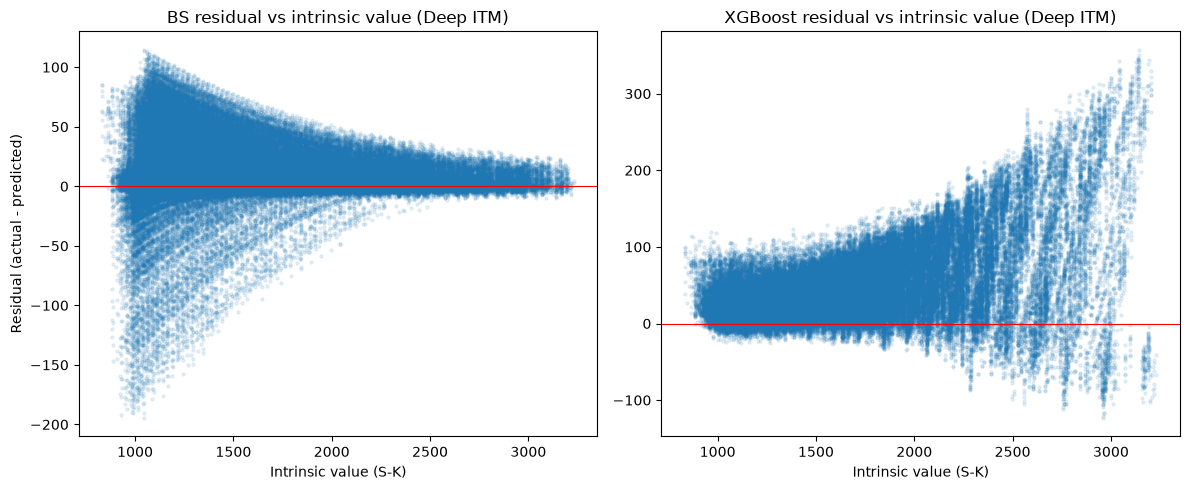

In [30]:
# Visualize: does XGBoost's error grow as intrinsic value grows?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(deep_itm["intrinsic_value"], deep_itm["bs_residual"], alpha=0.1, s=5)
axes[0].axhline(0, color="red", linewidth=0.8)
axes[0].set_title("BS residual vs intrinsic value (Deep ITM)")
axes[0].set_xlabel("Intrinsic value (S-K)")
axes[0].set_ylabel("Residual (actual - predicted)")

axes[1].scatter(deep_itm["intrinsic_value"], deep_itm["xgb_residual"], alpha=0.1, s=5)
axes[1].axhline(0, color="red", linewidth=0.8)
axes[1].set_title("XGBoost residual vs intrinsic value (Deep ITM)")
axes[1].set_xlabel("Intrinsic value (S-K)")

plt.tight_layout()
plt.show()

## Saving data for graph

In [31]:
print(train_val.shape)
print(final_model.get_params())

(6537806, 19)
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [32]:
joblib.dump(final_model, "xgb_spx_model.pkl")
print("saved xgboost")

saved xgboost


In [34]:
joblib.dump({"best_params": best_params,
             "models": {"v4": final_model},
             "test_preds": {"v4": y_test_pred}},
            "xgb_spx_preds.pkl")
print("saved")

saved
